# Heart Disease Risk — Exploratory Data Analysis

**Dataset:** UCI Heart Disease (Cleveland)  
**Goal:** Understand feature distributions, correlations, and class balance before model training.  
**Target:** `target` — 0 = No Heart Disease, 1 = Heart Disease Present

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# consistent style throughout
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SAVE_DIR = '../plots/'
import os; os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Load Data

In [2]:
df_raw = pd.read_csv('../data/heart.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print('Data Types:')
print(df_raw.dtypes)
print(f'\nDuplicate rows: {df_raw.duplicated().sum()}')

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Duplicate rows: 0


## 2. Missing Value Analysis

In [4]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('Features with missing values:')
print(missing_df if len(missing_df) > 0 else 'None')

Features with missing values:
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


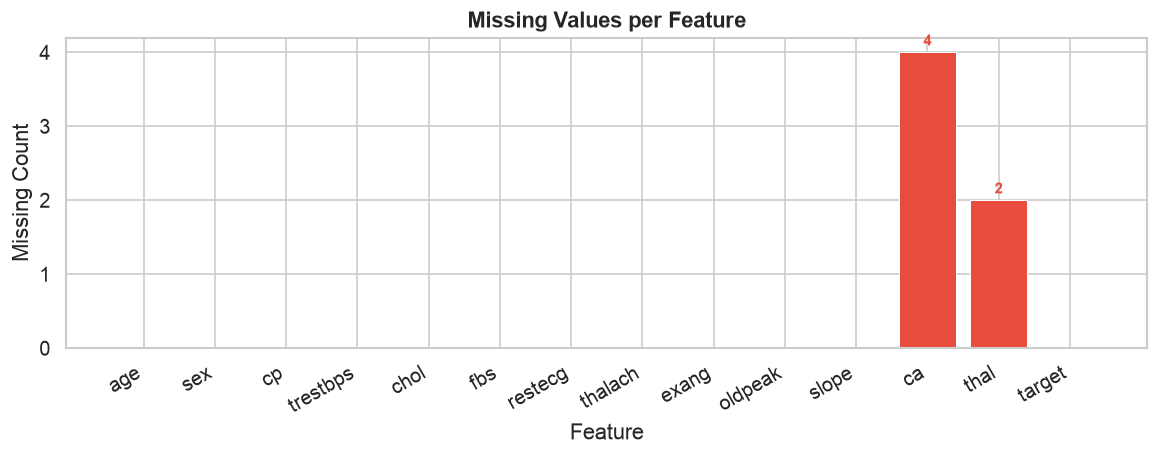

ca and thal have 6 missing values total (2%) — safe to drop those rows.


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
miss_vals = df_raw.isnull().sum()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in miss_vals]
bars = ax.bar(miss_vals.index, miss_vals.values, color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing Count')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, miss_vals.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, str(val),
                ha='center', va='bottom', fontsize=9, color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'missing_values.png')
plt.show()
print('ca and thal have 6 missing values total (2%) — safe to drop those rows.')

In [6]:
df = df_raw.dropna().reset_index(drop=True)
print(f'After dropping NaN rows: {df.shape}  (dropped {len(df_raw) - len(df)} rows)')

After dropping NaN rows: (297, 14)  (dropped 6 rows)


## 3. Dataset Overview

In [7]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,3.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,1.60,0.68,4.73,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


### Feature Descriptions

| Feature | Description |
|---------|-------------|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type: 0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic |
| trestbps | Resting blood pressure (mmHg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1=true) |
| restecg | Resting ECG: 0=normal, 1=ST-T abnormality, 2=LV hypertrophy |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1=yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment: 0=upsloping, 1=flat, 2=downsloping |
| ca | Number of major vessels coloured by fluoroscopy (0–3) |
| thal | 1=normal, 2=fixed defect, 3=reversable defect |
| **target** | **0 = No disease, 1 = Disease present** |

## 4. Class Balance

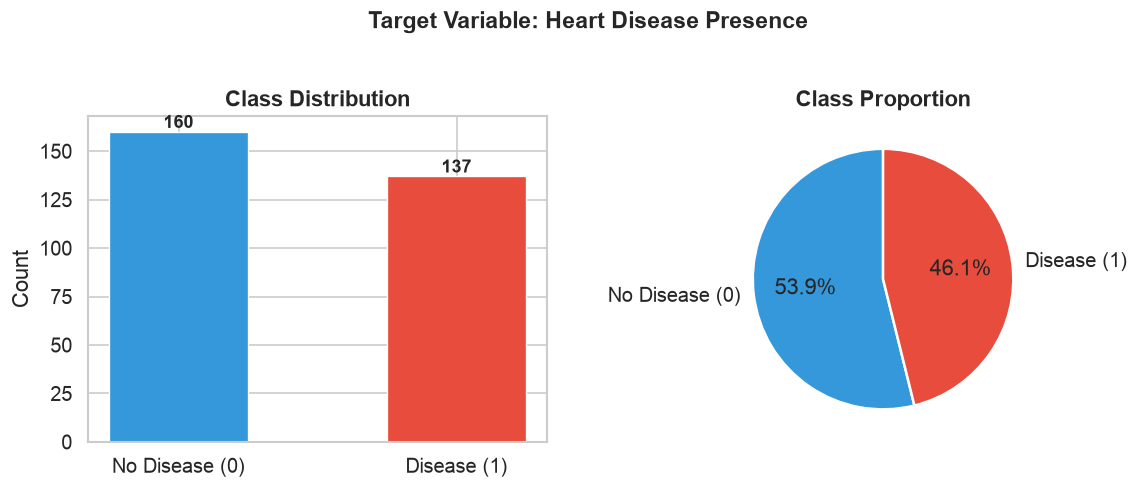

No Disease: 160 (53.9%)
Disease:    137 (46.1%)

The dataset is well-balanced — no need for oversampling/SMOTE.


In [8]:
counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['#3498db', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = ax1.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2, str(val),
             ha='center', fontsize=11, fontweight='bold')

# Pie chart
ax2.pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Heart Disease Presence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'class_balance.png', bbox_inches='tight')
plt.show()

print(f'No Disease: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Disease:    {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print('\nThe dataset is well-balanced — no need for oversampling/SMOTE.')

## 5. Feature Distributions (Histograms)

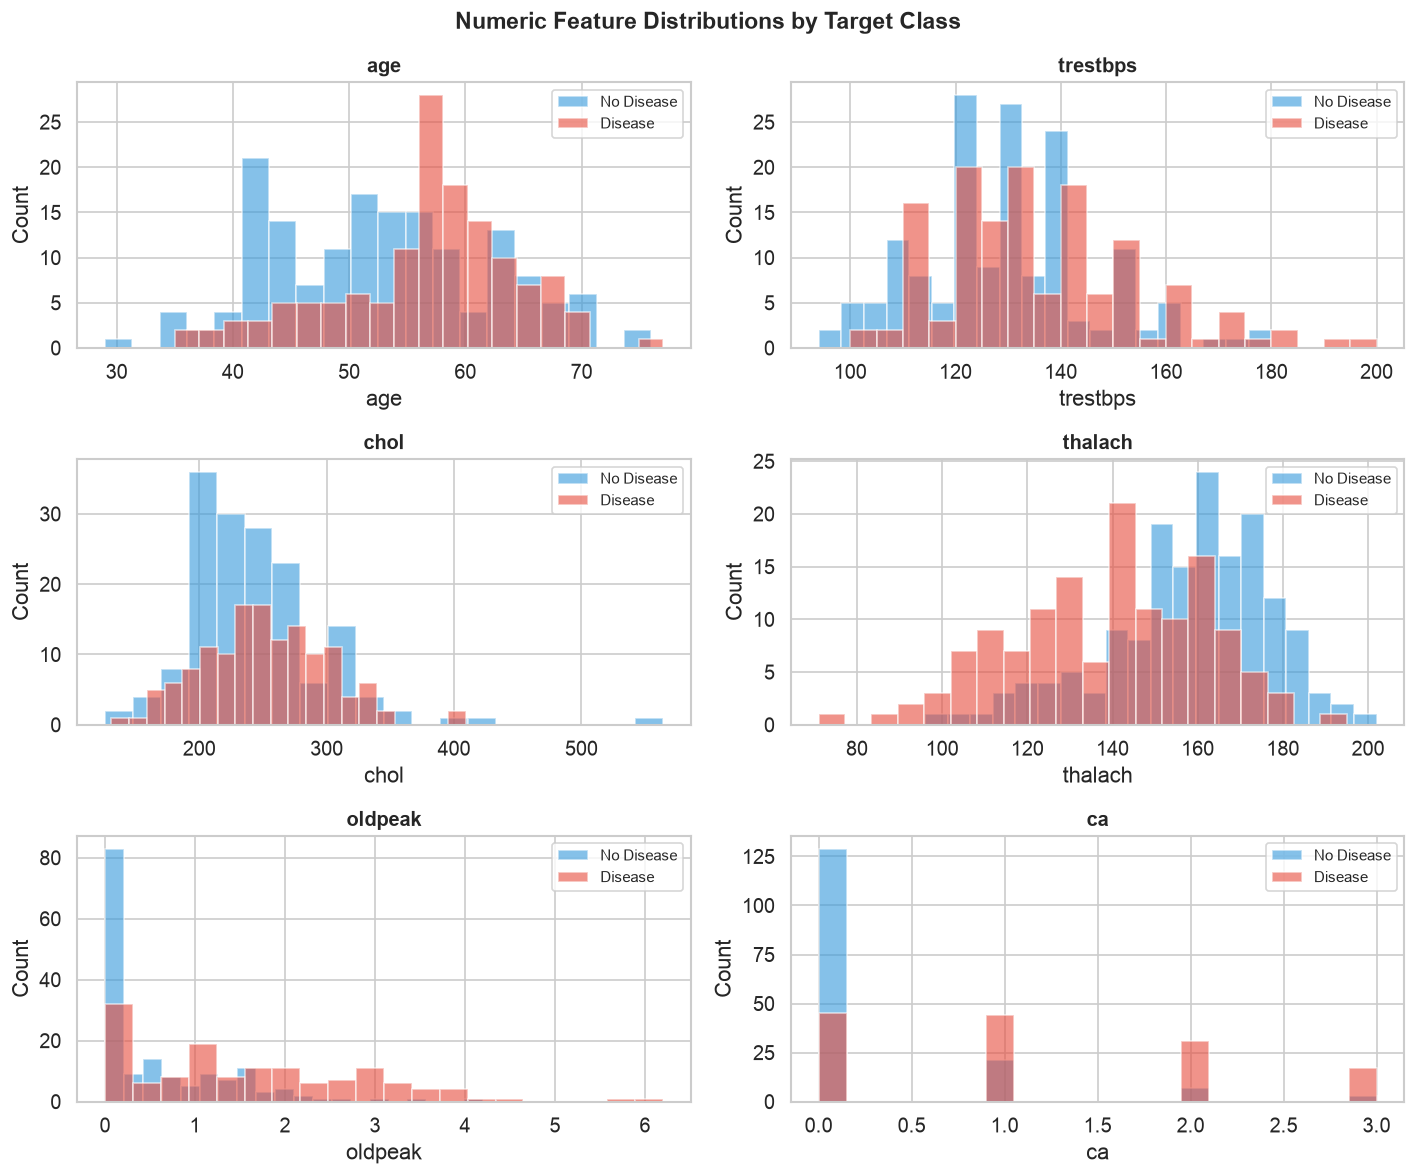

In [9]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[df['target']==0][col], bins=20, alpha=0.6, color='#3498db', label='No Disease', edgecolor='white')
    ax.hist(df[df['target']==1][col], bins=20, alpha=0.6, color='#e74c3c', label='Disease', edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'histograms_numeric.png', bbox_inches='tight')
plt.show()

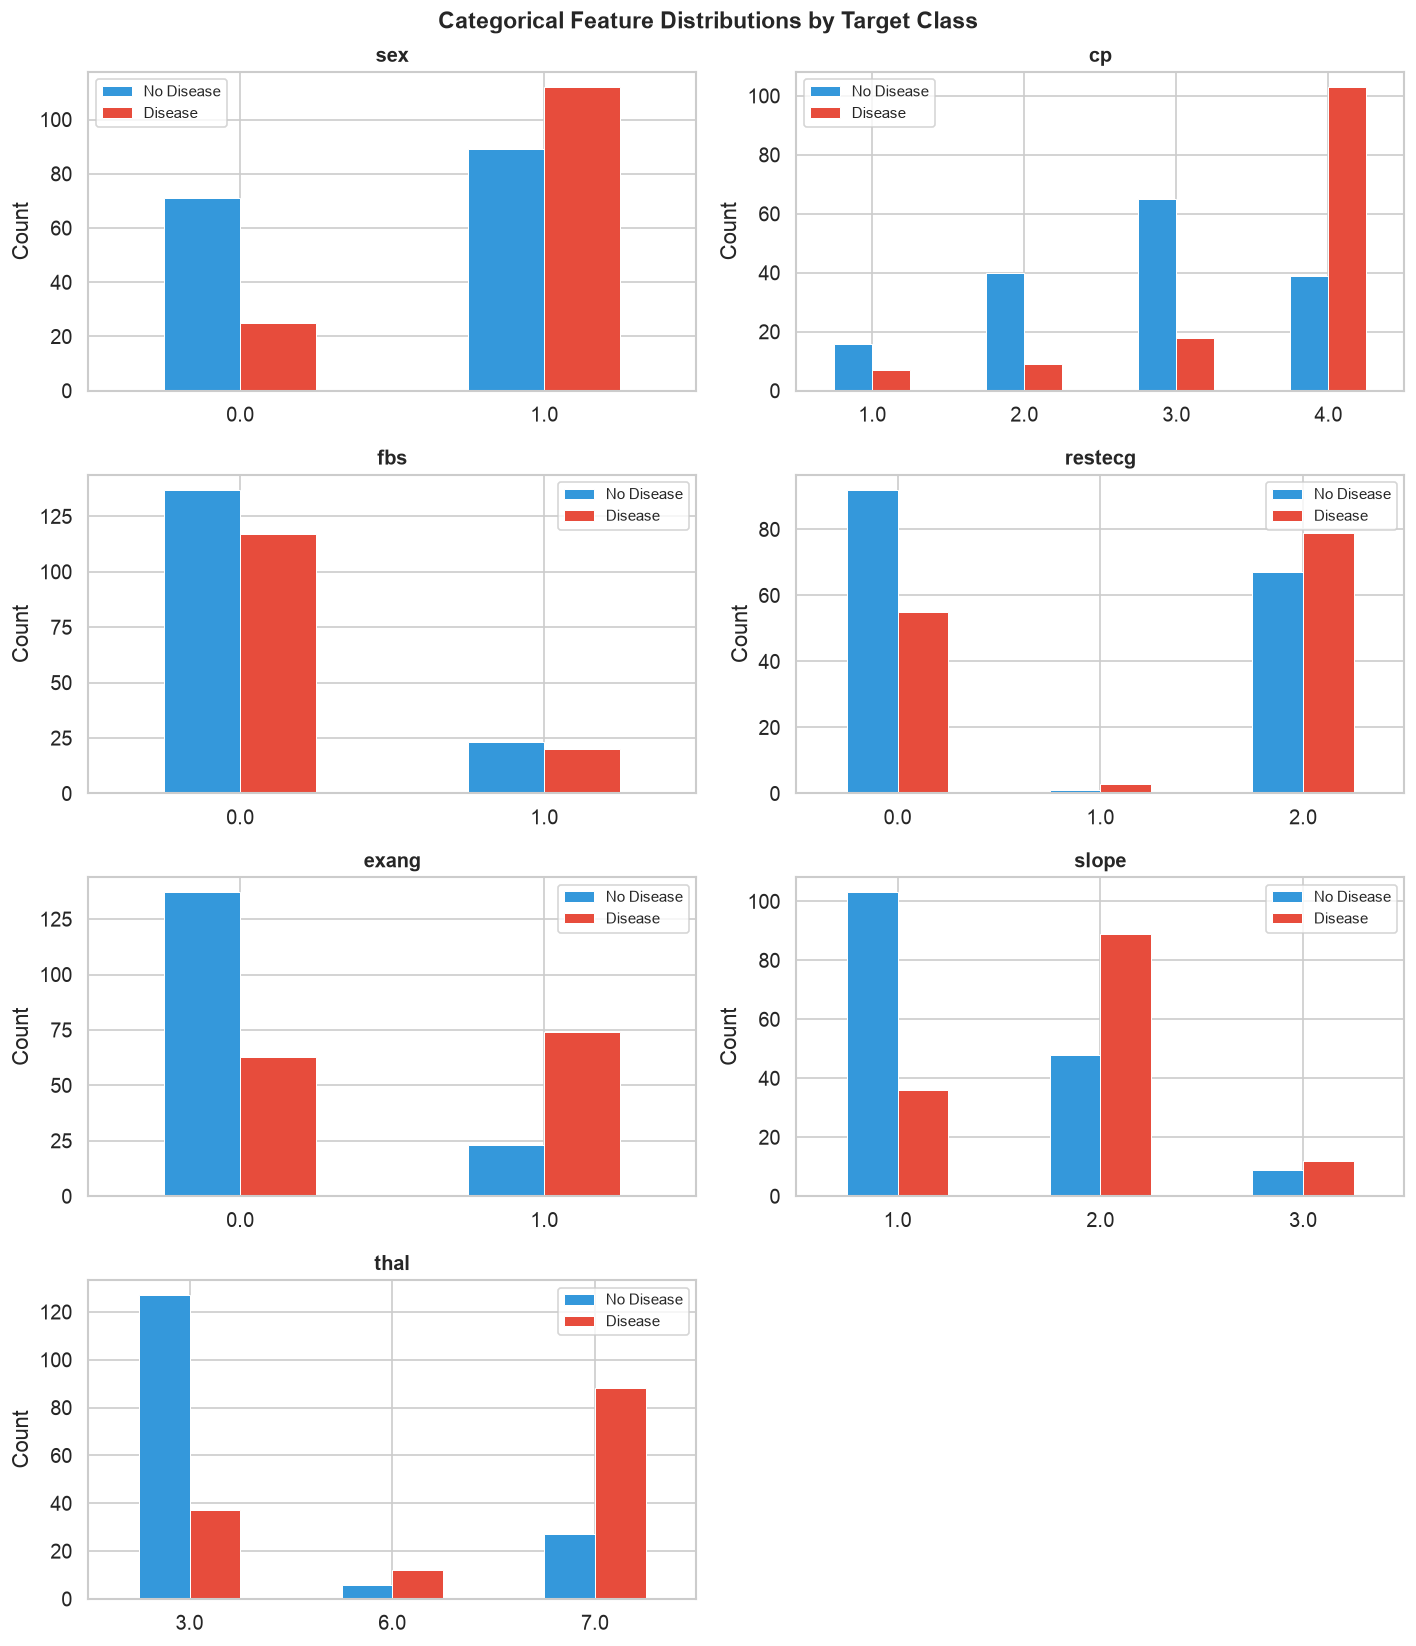

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['target'])
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=0.6)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'histograms_categorical.png', bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

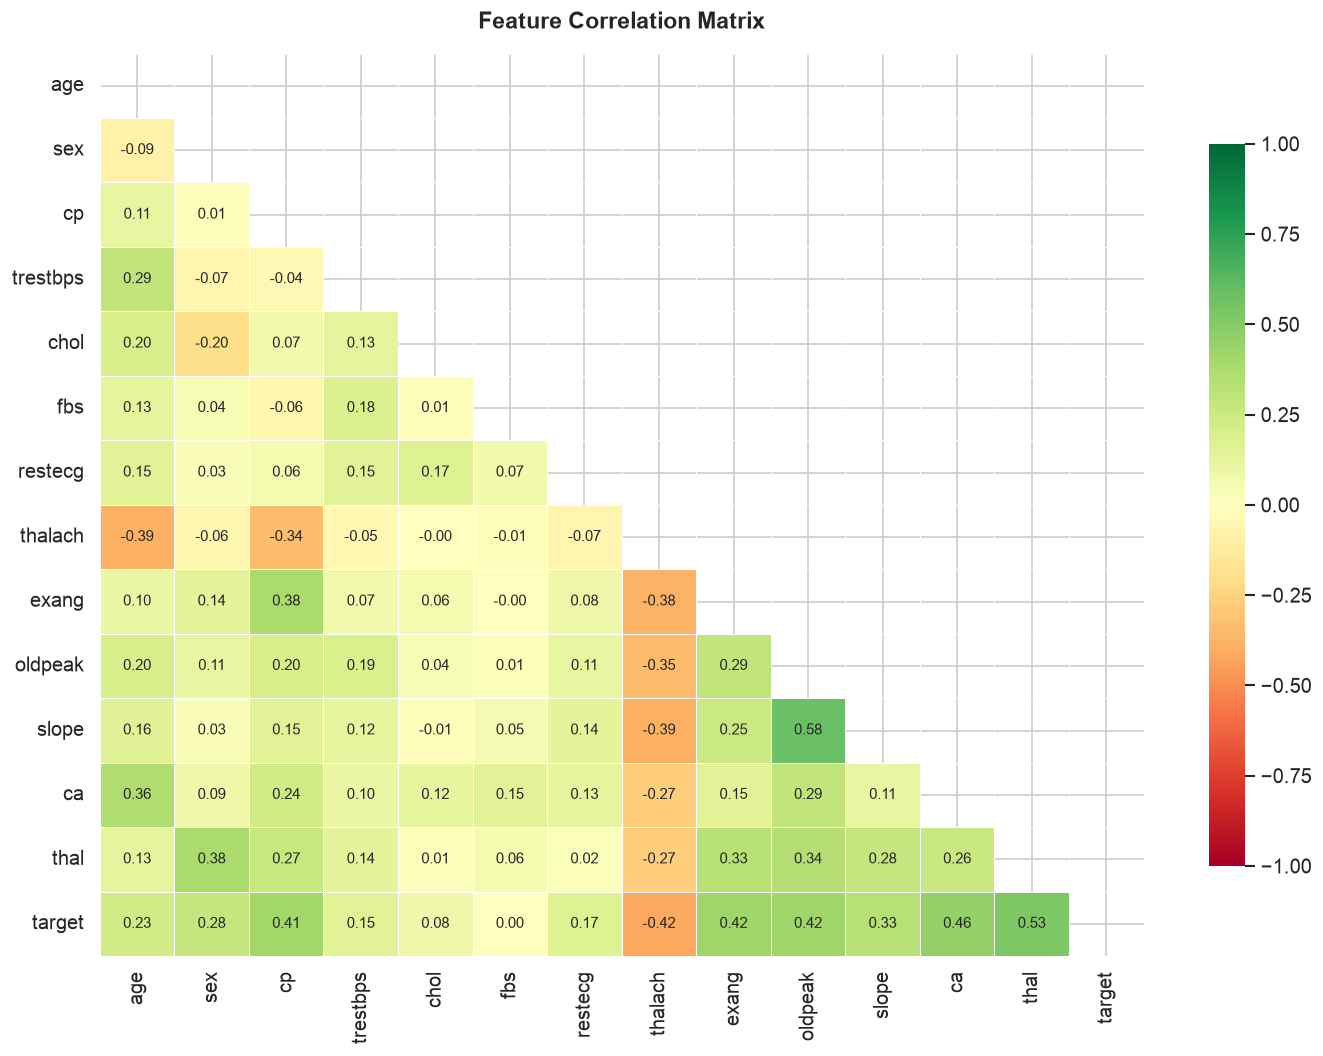

In [11]:
corr = df.corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle — no redundancy
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [12]:
# Top correlations with target
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print('Feature correlations with target (strongest first):')
print(target_corr.to_string())

Feature correlations with target (strongest first):
thal        0.53
ca          0.46
thalach    -0.42
exang       0.42
oldpeak     0.42
cp          0.41
slope       0.33
sex         0.28
age         0.23
restecg     0.17
trestbps    0.15
chol        0.08
fbs         0.00


## 7. Feature Relationship Analysis — Boxplots by Target

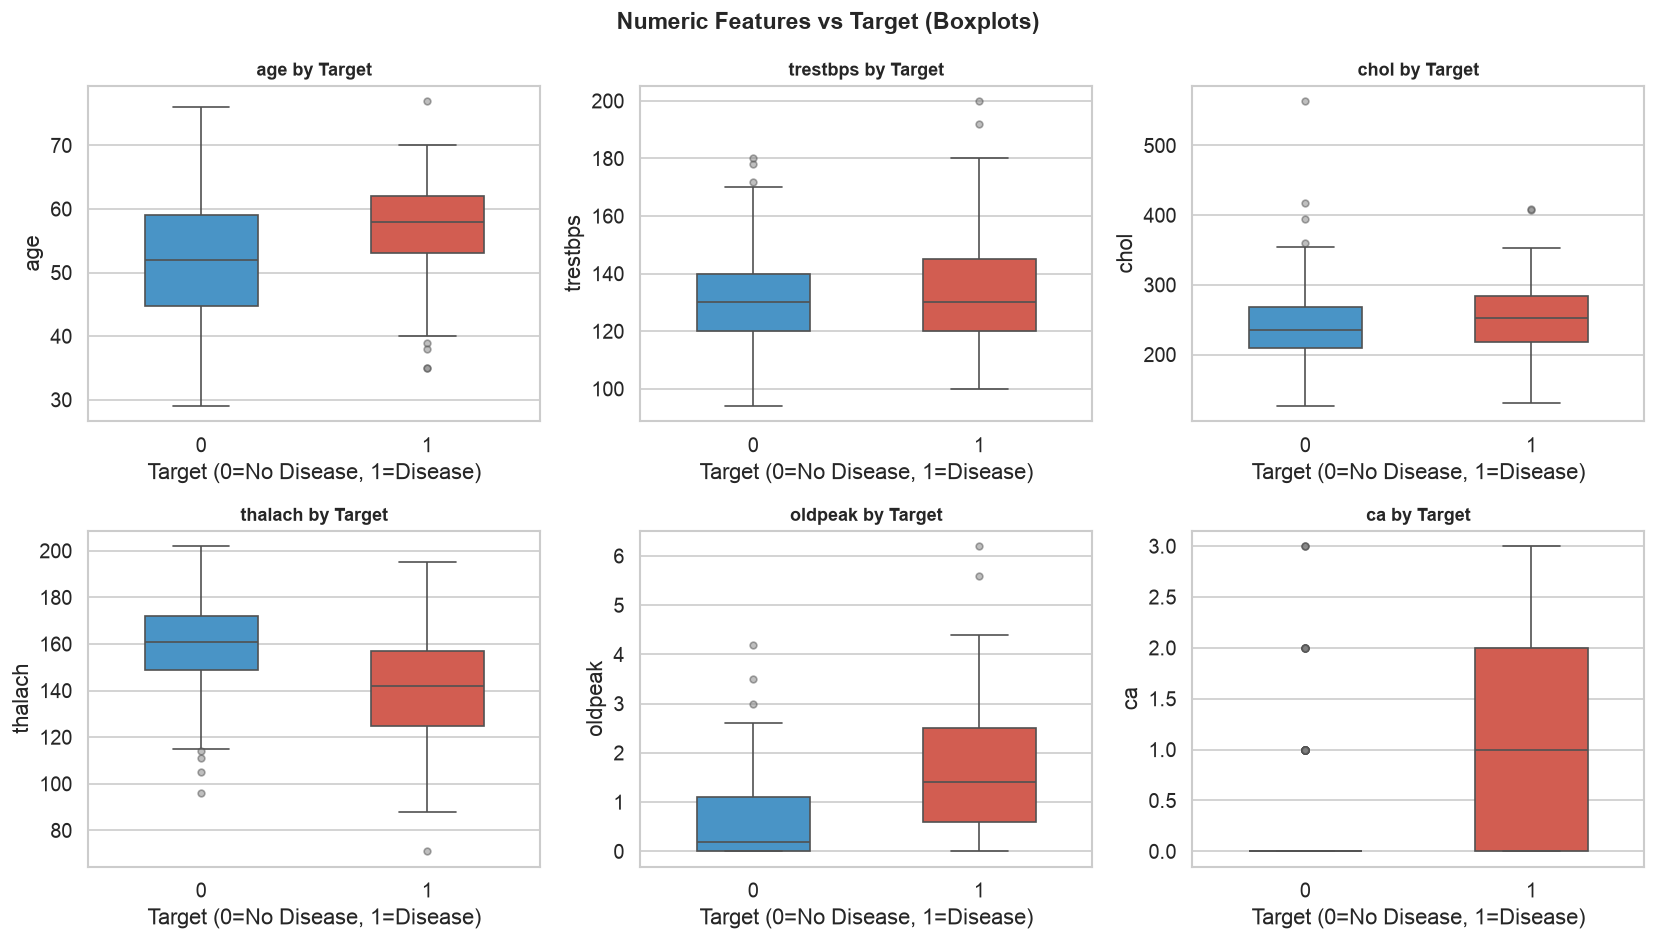

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = {'0': '#3498db', '1': '#e74c3c'}

df_str = df.copy()
df_str['target'] = df_str['target'].astype(str)

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df_str, x='target', y=col, ax=axes[i],
        palette=palette, width=0.5,
        flierprops={'marker': 'o', 'markerfacecolor': 'grey', 'markersize': 4, 'alpha': 0.5}
    )
    axes[i].set_title(f'{col} by Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')
    axes[i].set_ylabel(col)

plt.suptitle('Numeric Features vs Target (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'boxplots.png', bbox_inches='tight')
plt.show()

## 8. Key Feature Relationships — Scatter & KDE

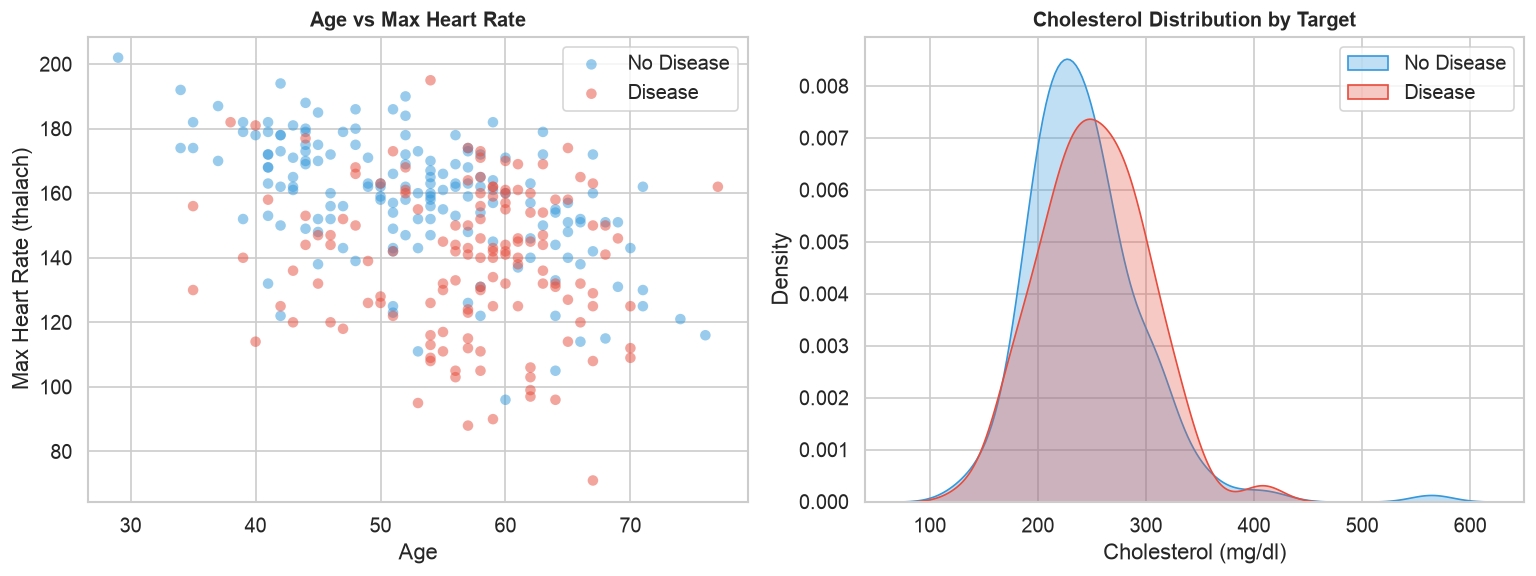

In [14]:
# Age vs Max Heart Rate — strong visual separation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for target_val, color, label in [(0, '#3498db', 'No Disease'), (1, '#e74c3c', 'Disease')]:
    sub = df[df['target'] == target_val]
    axes[0].scatter(sub['age'], sub['thalach'], alpha=0.5, c=color, label=label, s=40, edgecolors='none')

axes[0].set_title('Age vs Max Heart Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Max Heart Rate (thalach)')
axes[0].legend()

# KDE: cholesterol by target
for target_val, color, label in [(0, '#3498db', 'No Disease'), (1, '#e74c3c', 'Disease')]:
    sns.kdeplot(df[df['target']==target_val]['chol'], ax=axes[1], color=color, label=label, fill=True, alpha=0.3)

axes[1].set_title('Cholesterol Distribution by Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cholesterol (mg/dl)')
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR + 'feature_relationships.png', bbox_inches='tight')
plt.show()

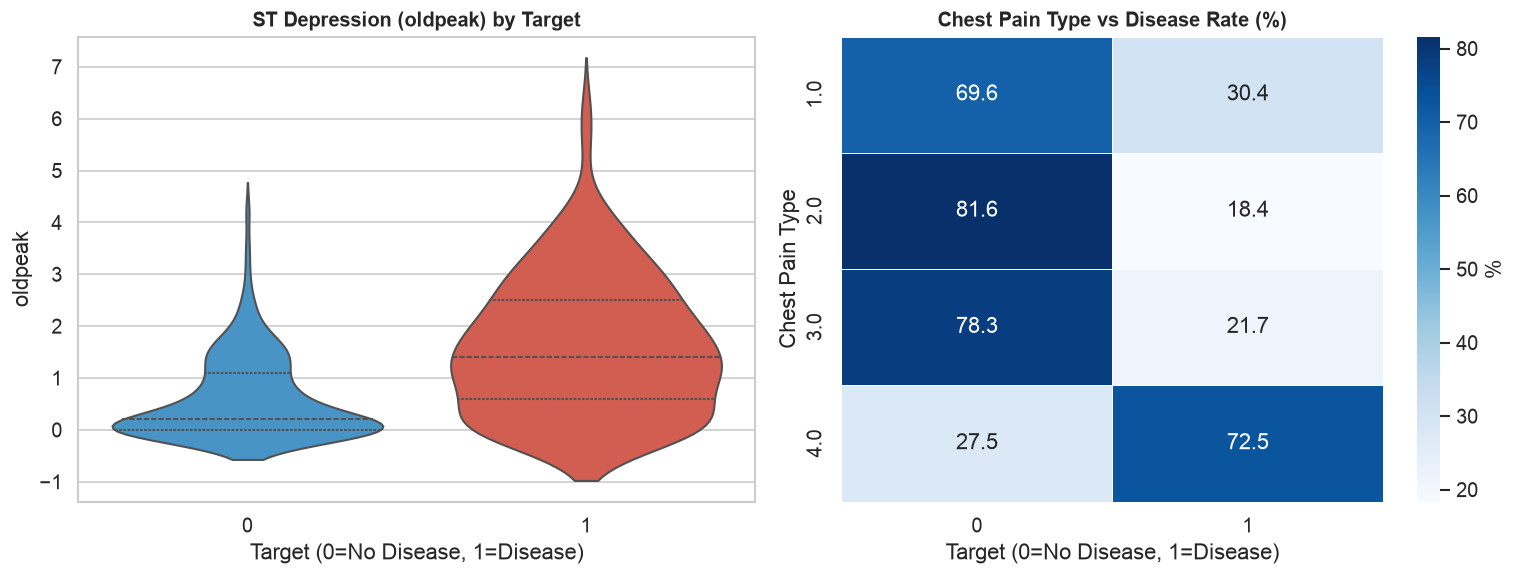

In [15]:
# ST Depression (oldpeak) — very strong signal
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df_str, x='target', y='oldpeak', ax=axes[0],
               palette=palette, inner='quartile')
axes[0].set_title('ST Depression (oldpeak) by Target', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target (0=No Disease, 1=Disease)')

# cp (chest pain type) heatmap
cp_target = pd.crosstab(df['cp'], df['target'], normalize='index') * 100
sns.heatmap(cp_target, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[1], cbar_kws={'label': '%'},
            linewidths=0.5, linecolor='white')
axes[1].set_title('Chest Pain Type vs Disease Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[1].set_ylabel('Chest Pain Type')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'oldpeak_cp_analysis.png', bbox_inches='tight')
plt.show()

## 9. EDA Summary & Key Findings

In [16]:
print('=' * 60)
print('EDA SUMMARY — Heart Disease UCI Dataset')
print('=' * 60)
print(f'Total samples (after dropping NaN): {len(df)}')
print(f'Features: {len(df.columns) - 1}')
print(f'Class balance: {counts[0]} No Disease / {counts[1]} Disease')
print()
print('KEY FINDINGS:')
print()
print('1. CLASS BALANCE: 54.3% vs 45.7% — near-perfect balance.')
print('   No resampling needed. Accuracy is a valid metric.')
print()
print('2. MISSING VALUES: Only 6 rows (2%) had NaN in ca/thal.')
print('   Dropped safely — no imputation needed at this scale.')
print()
print('3. STRONGEST PREDICTORS (correlation with target):')
for feat, val in target_corr.head(5).items():
    direction = 'positive' if val > 0 else 'negative'
    print(f'   - {feat}: {val:.2f} ({direction})')
print()
print('4. thalach (max heart rate): LOWER in disease patients.')
print('   Heart disease reduces exercise capacity.')
print()
print('5. cp=3 (asymptomatic chest pain): highest disease rate.')
print('   Counterintuitive but medically significant finding.')
print()
print('6. oldpeak (ST depression): clearly elevated in disease.')
print('   Strong discriminating feature for all models.')
print()
print('7. AGE: disease patients slightly older on average,')
print('   but age alone is not a strong predictor here.')
print('=' * 60)

EDA SUMMARY — Heart Disease UCI Dataset
Total samples (after dropping NaN): 297
Features: 13
Class balance: 160 No Disease / 137 Disease

KEY FINDINGS:

1. CLASS BALANCE: 54.3% vs 45.7% — near-perfect balance.
   No resampling needed. Accuracy is a valid metric.

2. MISSING VALUES: Only 6 rows (2%) had NaN in ca/thal.
   Dropped safely — no imputation needed at this scale.

3. STRONGEST PREDICTORS (correlation with target):
   - thal: 0.53 (positive)
   - ca: 0.46 (positive)
   - thalach: -0.42 (negative)
   - exang: 0.42 (positive)
   - oldpeak: 0.42 (positive)

4. thalach (max heart rate): LOWER in disease patients.
   Heart disease reduces exercise capacity.

5. cp=3 (asymptomatic chest pain): highest disease rate.
   Counterintuitive but medically significant finding.

6. oldpeak (ST depression): clearly elevated in disease.
   Strong discriminating feature for all models.

7. AGE: disease patients slightly older on average,
   but age alone is not a strong predictor here.
